Saved rolling_spillover.csv


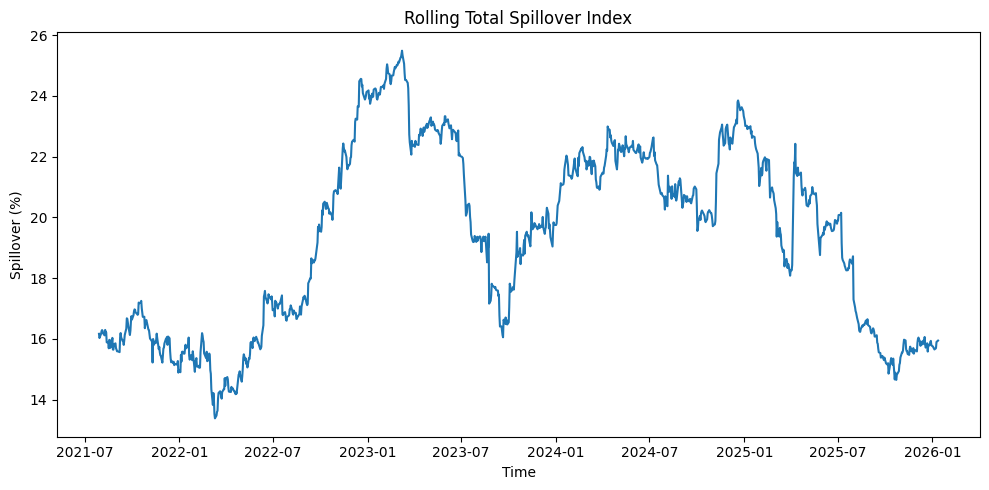

In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt

# ============================
# 설정
# ============================

DATA_PATH = "./merged_var_input.csv"

VARIABLES = [
    "dlog_SOLVPN",
    "dlog_COPPER",
    "dlog_DXY",
    "d_UST10Y",
    "dlog_VIX"
]

LAG = 1
HORIZON = 10
WINDOW = 200

# ============================
# 데이터 로드
# ============================

df = pd.read_csv(DATA_PATH)

if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date")

data = df[VARIABLES].dropna()

# ============================
# Rolling spillover 계산
# ============================

results = []

for start in range(len(data) - WINDOW):

    end = start + WINDOW

    window_data = data.iloc[start:end]

    try:
        model = VAR(window_data)
        res = model.fit(LAG)

        fevd = res.fevd(HORIZON)

        fevd_matrix = fevd.decomp[:, -1, :]

        fevd_df = pd.DataFrame(
            fevd_matrix,
            index=VARIABLES,
            columns=VARIABLES
        )

        spill = fevd_df.copy()
        np.fill_diagonal(spill.values, 0)

        # total spillover
        off_diag = spill.values.sum()
        total = fevd_df.values.sum()

        total_spill = off_diag / total * 100

        # directional
        FROM = spill.sum(axis=1) * 100
        TO = spill.sum(axis=0) * 100

        row = {
            "Date": df.iloc[end]["Date"],
            "Total_Spillover": total_spill,
            "SOLVPN_TO": TO["dlog_SOLVPN"],
            "SOLVPN_FROM": FROM["dlog_SOLVPN"],
            "COPPER_TO": TO["dlog_COPPER"],
            "COPPER_FROM": FROM["dlog_COPPER"]
        }

        results.append(row)

    except:
        continue

rolling_df = pd.DataFrame(results)

rolling_df.to_csv("rolling_spillover.csv", index=False)

print("Saved rolling_spillover.csv")

# ============================
# 그래프
# ============================

plt.figure(figsize=(10,5))

plt.plot(
    rolling_df["Date"],
    rolling_df["Total_Spillover"]
)

plt.title("Rolling Total Spillover Index")
plt.xlabel("Time")
plt.ylabel("Spillover (%)")

plt.tight_layout()

plt.savefig("rolling_spillover.png", dpi=300)

plt.show()